In [2]:
## Plant Disease Classification Using Deep Learning

In this project, We will use deep learning to classify Plant diseases. The dataset contains  leaf images  of three categories: healthy leaves, Yellow_Leaf_Curl_Virus-affected leaves, and Bacterial spot-affected leaves. The dataset is downloaded from Kaggle.

At the end of the first part of the lesson,each student will be abble to:
1. Read multiple images in a folder
2. Understand tensorflow and keras
3. Use the matplotlib library to plot images
4. Do data preprocessing
5. CNN model

SyntaxError: invalid syntax (2424501571.py, line 3)

In [5]:
#import librabries
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np

In [6]:
IMAGE_SIZE=256
BATCH_SIZE=32

In [7]:
images_dataset=tf.keras.preprocessing.image_dataset_from_directory(
 'PlantVillage',
 shuffle=True,
 image_size=(IMAGE_SIZE,IMAGE_SIZE),
 batch_size=BATCH_SIZE,
 
)

Found 11227 files belonging to 6 classes.


In [8]:
class_names=images_dataset.class_names
class_names

['Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Tomato_Bacterial_spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato_healthy']

In [9]:
len(images_dataset)

351

In [10]:
#exploring the dataset
for image_batch, label_batch in images_dataset.take(1):
    print(image_batch.shape)
    print(label_batch.numpy())

(32, 256, 256, 3)
[1 4 4 4 4 4 0 3 4 0 4 4 4 5 4 4 4 3 4 4 4 4 4 5 2 1 5 4 4 4 1 4]


In [11]:
#print first image in that batch
for image_batch, label_batch in images_dataset.take(1):
    print(image_batch[0].numpy())


[[[114. 115. 133.]
  [119. 120. 138.]
  [104. 105. 123.]
  ...
  [125. 123. 136.]
  [123. 121. 134.]
  [117. 115. 128.]]

 [[120. 121. 139.]
  [122. 123. 141.]
  [108. 109. 127.]
  ...
  [131. 129. 142.]
  [133. 131. 144.]
  [130. 128. 141.]]

 [[122. 123. 141.]
  [125. 126. 144.]
  [117. 118. 136.]
  ...
  [136. 134. 147.]
  [140. 138. 151.]
  [139. 137. 150.]]

 ...

 [[168. 171. 188.]
  [164. 167. 184.]
  [161. 164. 181.]
  ...
  [171. 173. 186.]
  [167. 169. 182.]
  [159. 161. 174.]]

 [[165. 168. 185.]
  [163. 166. 183.]
  [161. 164. 181.]
  ...
  [171. 173. 186.]
  [167. 169. 182.]
  [161. 163. 176.]]

 [[160. 163. 180.]
  [158. 161. 178.]
  [155. 158. 175.]
  ...
  [165. 167. 180.]
  [167. 169. 182.]
  [166. 168. 181.]]]


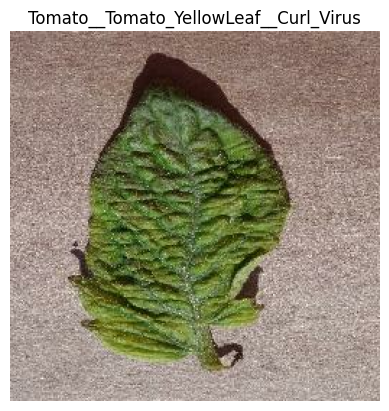

In [12]:
#visualize the first image in that batch
for image_batch, label_batch in images_dataset.take(1):
    plt.imshow(image_batch[0].numpy().astype('uint8'))
    plt.title(class_names[label_batch[0]])
    plt.axis('off')


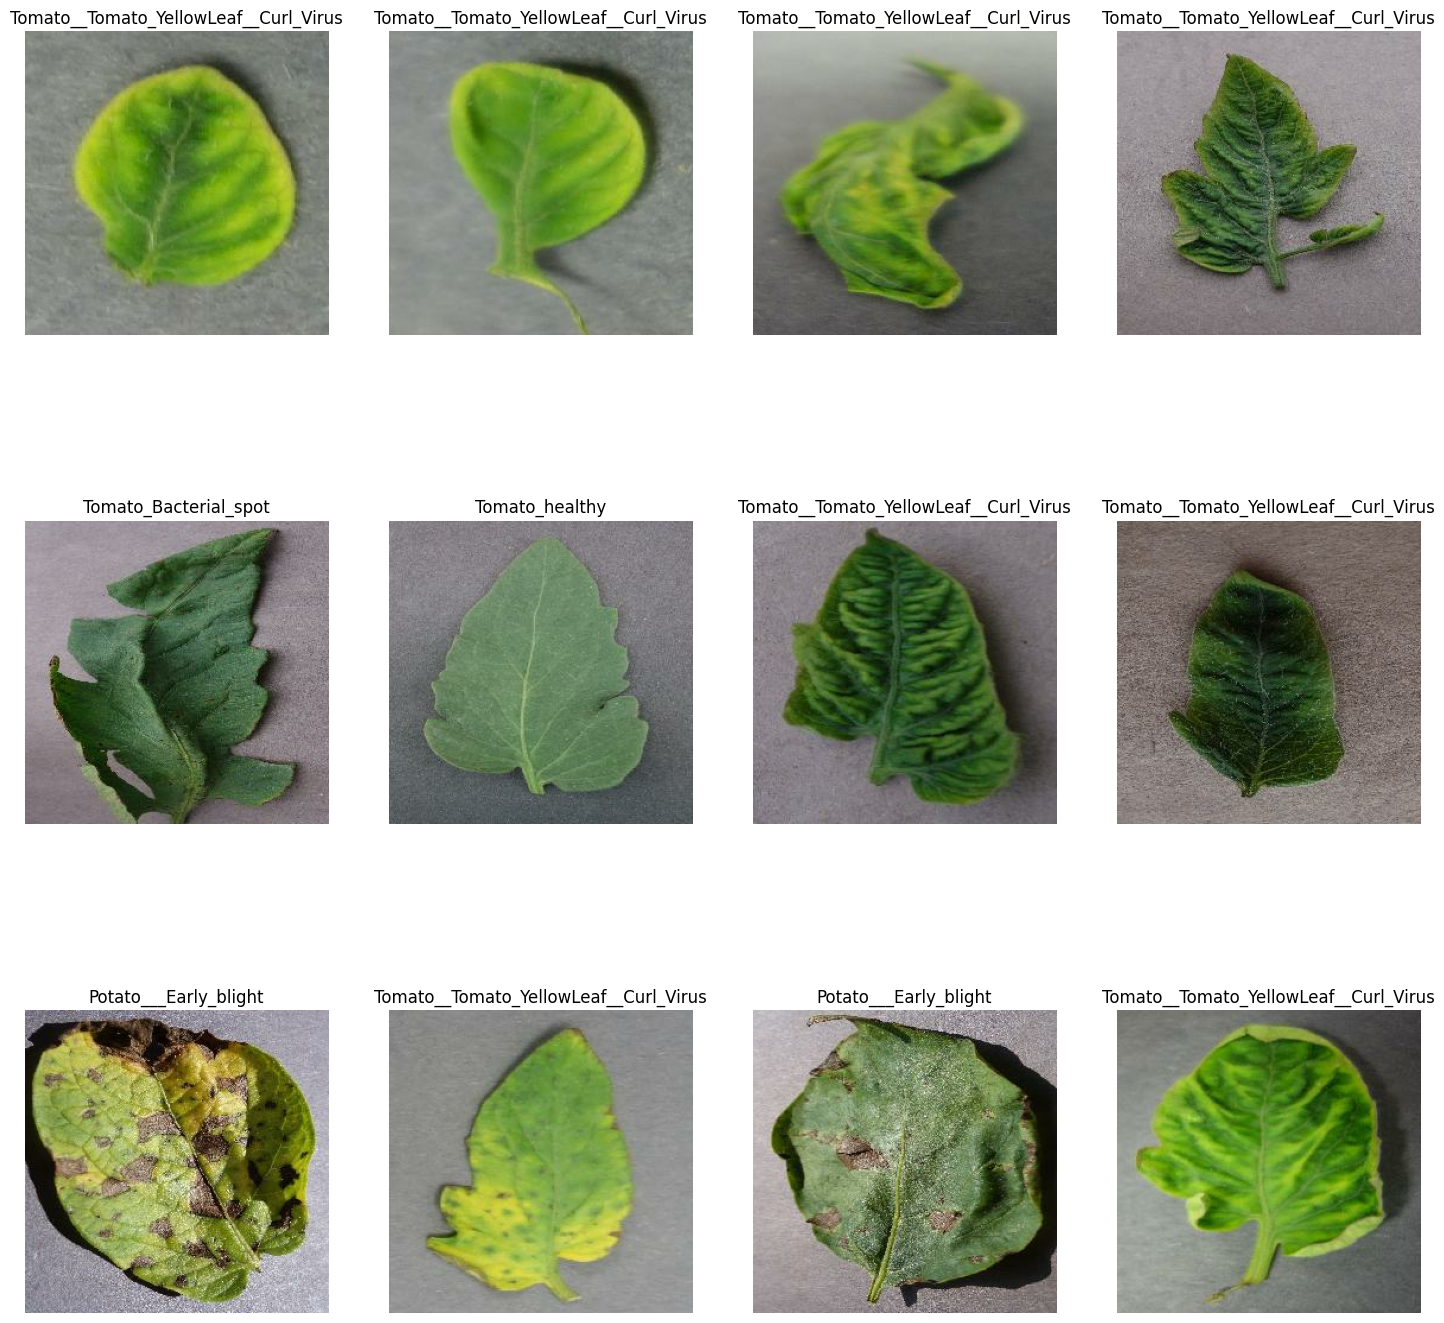

In [13]:
#visualize the first image in that batch
plt.figure(figsize=(18,18))
for image_batch, label_batch in images_dataset.take(1):
    for i in range (12):
        ax=plt.subplot(3,4, i+1)
        plt.imshow(image_batch[i].numpy().astype('uint8'))
        plt.title(class_names[label_batch[i]])
        plt.axis('off')

In [14]:
len(images_dataset)

351

In [15]:
def get_dataset_partitions_tf(ds,train_split=0.8, val_split=0.1, test_split=0.1,shuffle=True, shuffle_size=10000):
    ds_size=len(ds)
    if shuffle:
        ds=ds.shuffle(shuffle_size,seed=12)
        
    train_size= int(train_split* ds_size)
    val_size=int(val_split* ds_size)
    
    train_ds=ds.take(train_size)
    
    val_ds=ds.skip(train_size).take(val_size)
    
    test_ds=ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [16]:
train_ds, val_ds, test_ds=get_dataset_partitions_tf(images_dataset)

In [17]:
print(len(train_ds),len(val_ds),len(test_ds))


280 35 36


In [18]:
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
val_ds=val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
test_ds=test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.experimental.AUTOTUNE)

In [19]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1./255),
])

In [20]:
data_augmentation=tf.keras.Sequential([
    
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

In [21]:
#Convolutional Neural Network

In [ ]:
model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Train the model with fewer epochs and a subset of the dataset
history = model.fit(train_ds.take(50), validation_data=val_ds.take(20), epochs=4)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_ds)
print("Test accuracy:", test_accuracy)



Epoch 1/4


C:\Users\JCC\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\backend\tensorflow\nn.py:1216: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(
